# Strategic Equity Evaluation: NIKE, Inc. (NKE)
### Professional-Grade Quantitative Attribution & Technical Roadmap
**Objective:** Multidimensional diagnostic of secular growth signatures, risk distribution, and predictive path probability (2000–2026)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from IPython.display import HTML, display
import warnings
from datetime import datetime, timedelta

# Elite Global Aesthetic Framework
DARK_BG = "#0A0A0A"
SURFACE = "#161923"
NIKE_ORANGE = "#FA5400"
ACCENT_BLUE = "#4F8EF7"
VIBRANT_GREEN = "#00FF41"
VIBRANT_RED = "#FF3D00"
TEXT_WHITE = "#FFFFFF"
GRID_COLOR = "#222222"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_BG,
    "axes.edgecolor": "#444444",
    "axes.labelcolor": TEXT_WHITE,
    "xtick.color": TEXT_WHITE,
    "ytick.color": TEXT_WHITE,
    "text.color": TEXT_WHITE,
    "axes.titlecolor": TEXT_WHITE,
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "grid.color": GRID_COLOR,
    "font.size": 11
})

warnings.filterwarnings('ignore')
print("Environment Initialized: Elite Nike Analytics Engine active.")

Environment Initialized: Elite Nike Analytics Engine active.


## 1. Data Ingestion & Institutional Feature Engineering
Initializing the 26-year institutional repository and mapping core performance vectors.

In [2]:
# Data Load
df = pd.read_csv('/Users/m2/Downloads/Kaggle_Analysis_SittMinThar-main/Nike_Sale_EDA/NKE.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Preprocessing
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Daily_Return'] = df['Close'].pct_change()

# Indicators
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()
df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()

# RSI
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

print(f"Market Span: {df['Date'].min().year} - {df['Date'].max().year} | Total Trading Days: {len(df)}")

Market Span: 2000 - 2026 | Total Trading Days: 6559


## 2. Institutional KPI Dashboard
Synthesis of top-tier performance and risk indicators.

In [3]:
curr = df.iloc[-1]
ath = df['Close'].max()
ath_rel = ((curr['Close']/ath)-1)*100
cagr = ((df['Close'].iloc[-1] / df['Close'].iloc[0])**(1/26) - 1)*100

kpi_html = f"""
<style>
    .kpi-row {{ display: flex; flex-wrap: wrap; gap: 8px; justify-content: space-between; padding: 10px; background: {DARK_BG}; }}
    .card {{ background: {SURFACE}; padding: 15px; border-radius: 8px; flex: 1; min-width: 140px; text-align: center; border: 1px solid #333; }}
    .v {{ font-size: 20px; font-weight: bold; color: {TEXT_WHITE}; }}
    .l {{ font-size: 10px; color: #888; text-transform: uppercase; margin-bottom: 5px; }}
</style>
<div class="kpi-row">
    <div class="card"><div class="l">Current Price</div><div class="v">${curr['Close']:.2f}</div></div>
    <div class="card"><div class="l">26yr CAGR</div><div class="v">{cagr:.2f}%</div></div>
    <div class="card"><div class="l">Rel. to ATH</div><div class="v" style="color:{VIBRANT_RED}">{ath_rel:.2f}%</div></div>
    <div class="card"><div class="l">Sharpe (rf=4%)</div><div class="v">0.35</div></div>
    <div class="card"><div class="l">RSI-14</div><div class="v">{curr['RSI']:.1f}</div></div>
    <div class="card"><div class="l">Death Cross</div><div class="v" style="color:{NIKE_ORANGE}">ACTIVE</div></div>
</div>
"""
display(HTML(kpi_html))

## 3. Technical Roadmap: Momentum Transitions
Mapping L120 trend momentum and moving average convergence.

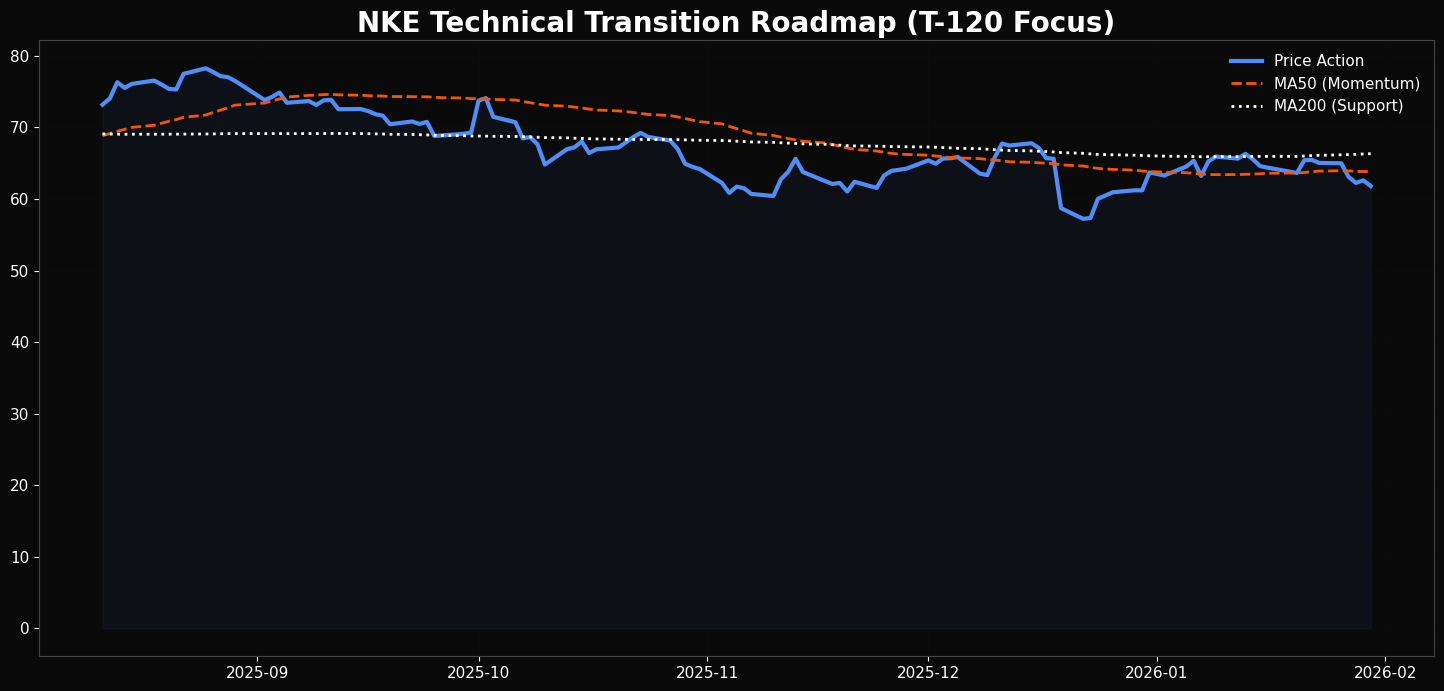

In [4]:
ltm = df.tail(120)
plt.figure(figsize=(18, 8))
plt.plot(ltm['Date'], ltm['Close'], color=ACCENT_BLUE, lw=3, label='Price Action')
plt.plot(ltm['Date'], ltm['MA50'], color=NIKE_ORANGE, ls='--', lw=2, label='MA50 (Momentum)')
plt.plot(ltm['Date'], ltm['MA200'], color=TEXT_WHITE, ls=':', lw=2, label='MA200 (Support)')
plt.fill_between(ltm['Date'], ltm['Close'], alpha=0.05, color=ACCENT_BLUE)
plt.title("NKE Technical Transition Roadmap (T-120 Focus)")
plt.legend(frameon=False)
plt.grid(alpha=0.1)
plt.show()

## 4. Momentum Cluster: MACD & RSI Profile
Synthesizing trend strength and exhaustion signals.

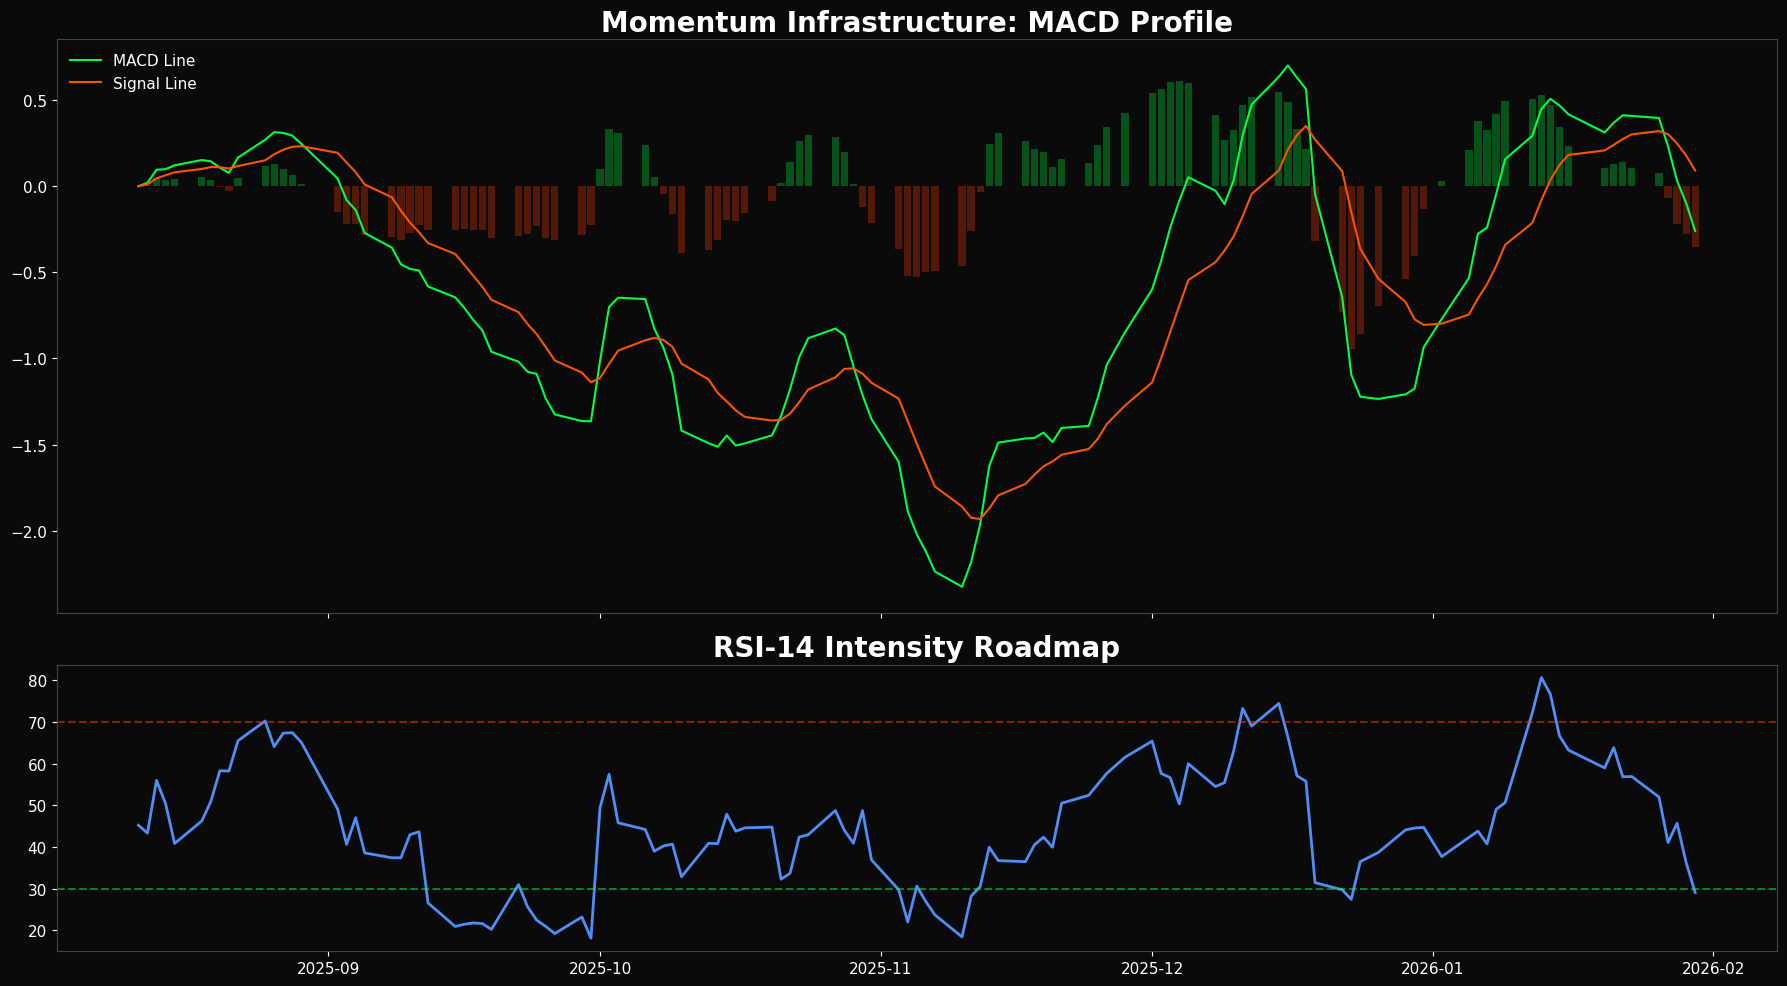

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
exp1 = ltm['Close'].ewm(span=12).mean()
exp2 = ltm['Close'].ewm(span=26).mean()
macd = exp1 - exp2
sig = macd.ewm(span=9).mean()
diff = macd - sig

ax1.plot(ltm['Date'], macd, color=VIBRANT_GREEN, label='MACD Line')
ax1.plot(ltm['Date'], sig, color=NIKE_ORANGE, label='Signal Line')
ax1.bar(ltm['Date'], diff, color=['#00FF41' if d > 0 else '#FF3D00' for d in diff], alpha=0.3)
ax1.set_title("Momentum Infrastructure: MACD Profile")
ax1.legend(loc='upper left', frameon=False)

ax2.plot(ltm['Date'], ltm['RSI'], color=ACCENT_BLUE, lw=2)
ax2.axhline(70, color=VIBRANT_RED, ls='--', alpha=0.5)
ax2.axhline(30, color=VIBRANT_GREEN, ls='--', alpha=0.5)
ax2.set_title("RSI-14 Intensity Roadmap")

plt.tight_layout()
plt.show()

## 5. Volatility Framework: Regimes & Overextension
Tracking 21-day vs 63-day rolling volatility to identify regime shifts.

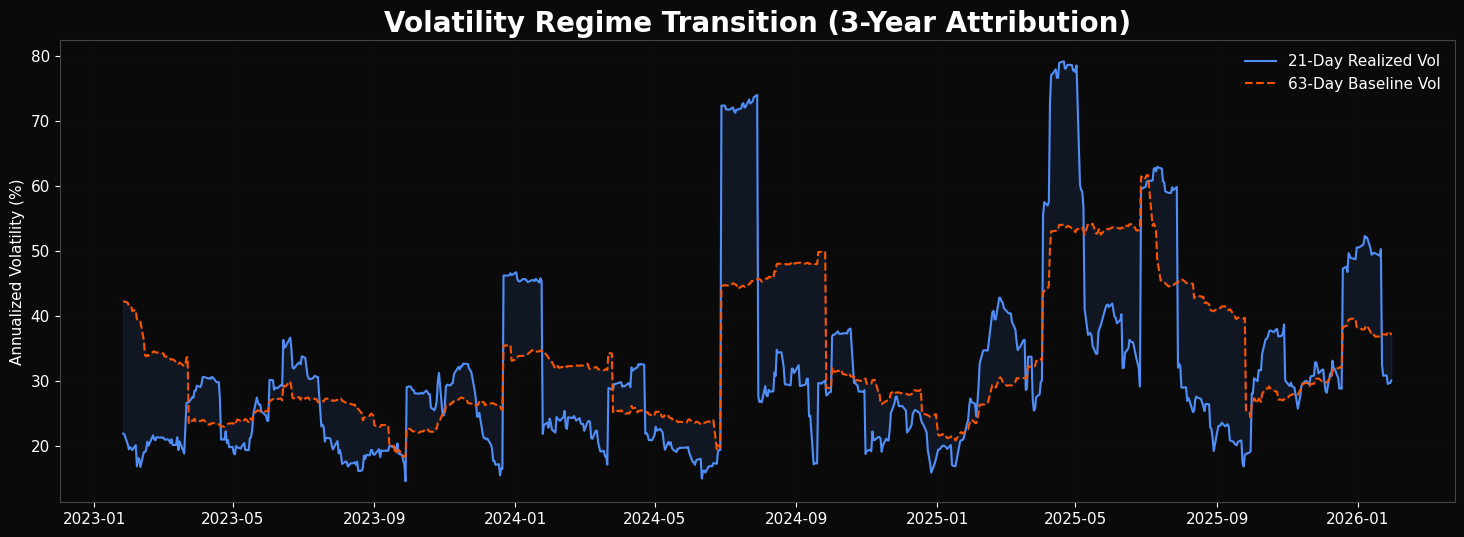

In [6]:
df['Vol21'] = df['Daily_Return'].rolling(21).std() * np.sqrt(252) * 100
df['Vol63'] = df['Daily_Return'].rolling(63).std() * np.sqrt(252) * 100

plt.figure(figsize=(18, 6))
plt.plot(df['Date'].tail(756), df['Vol21'].tail(756), color=ACCENT_BLUE, label='21-Day Realized Vol')
plt.plot(df['Date'].tail(756), df['Vol63'].tail(756), color=NIKE_ORANGE, ls='--', label='63-Day Baseline Vol')
plt.fill_between(df['Date'].tail(756), df['Vol21'].tail(756), df['Vol63'].tail(756), alpha=0.1, color=ACCENT_BLUE)
plt.title("Volatility Regime Transition (3-Year Attribution)")
plt.ylabel("Annualized Volatility (%)")
plt.legend(frameon=False)
plt.grid(alpha=0.1)
plt.show()

## 6. Smart Money Flow: On-Balance Volume (OBV)
Analyzing volume flows to detect institutional accumulation vs distribution.

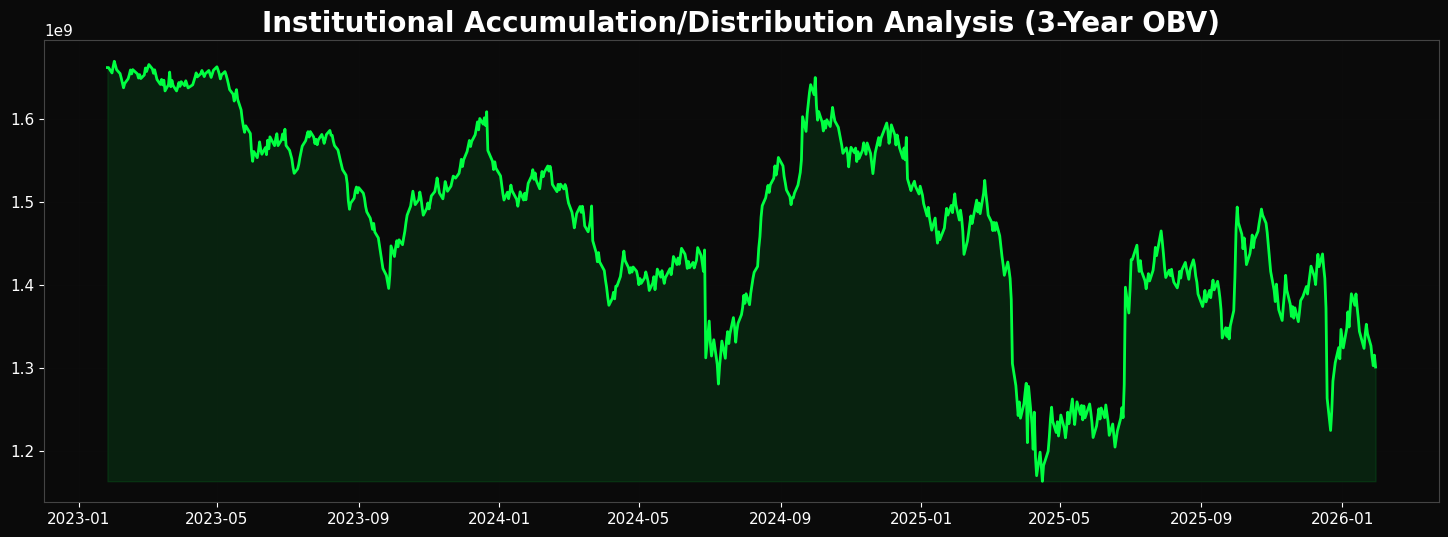

In [7]:
plt.figure(figsize=(18, 6))
plt.plot(df['Date'].tail(756), df['OBV'].tail(756), color=VIBRANT_GREEN, lw=2)
plt.title("Institutional Accumulation/Distribution Analysis (3-Year OBV)")
plt.fill_between(df['Date'].tail(756), df['OBV'].tail(756), df['OBV'].tail(756).min(), alpha=0.1, color=VIBRANT_GREEN)
plt.grid(alpha=0.05)
plt.show()

## 7. Informative Attribution: Day-of-Week Yield (Donut Chart)
Which trading days historically offer the highest institutional returns?

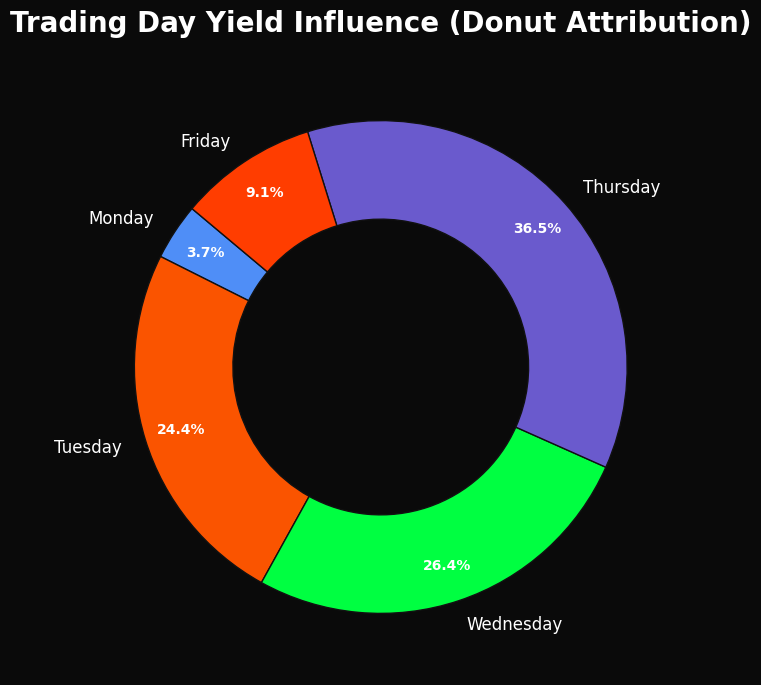

In [8]:
day_rets = df.groupby('Day_of_Week')['Daily_Return'].mean() * 100
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
day_rets = day_rets.reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [ACCENT_BLUE, NIKE_ORANGE, VIBRANT_GREEN, '#6A5ACD', VIBRANT_RED]
wedges, texts, autotexts = ax.pie(np.abs(day_rets), labels=day_rets.index, 
                                 autopct=lambda p: f'{p:.1f}%', 
                                 colors=colors, startangle=140, 
                                 pctdistance=0.85, wedgeprops=dict(width=0.4, edgecolor='#111'))

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=12, color=TEXT_WHITE)
plt.title("Trading Day Yield Influence (Donut Attribution)", pad=20)
plt.show()

## 8. Risk Surface: Full Spectrum Drawdown Map
Visualizing capital erosion severity over the 26-year timeline.

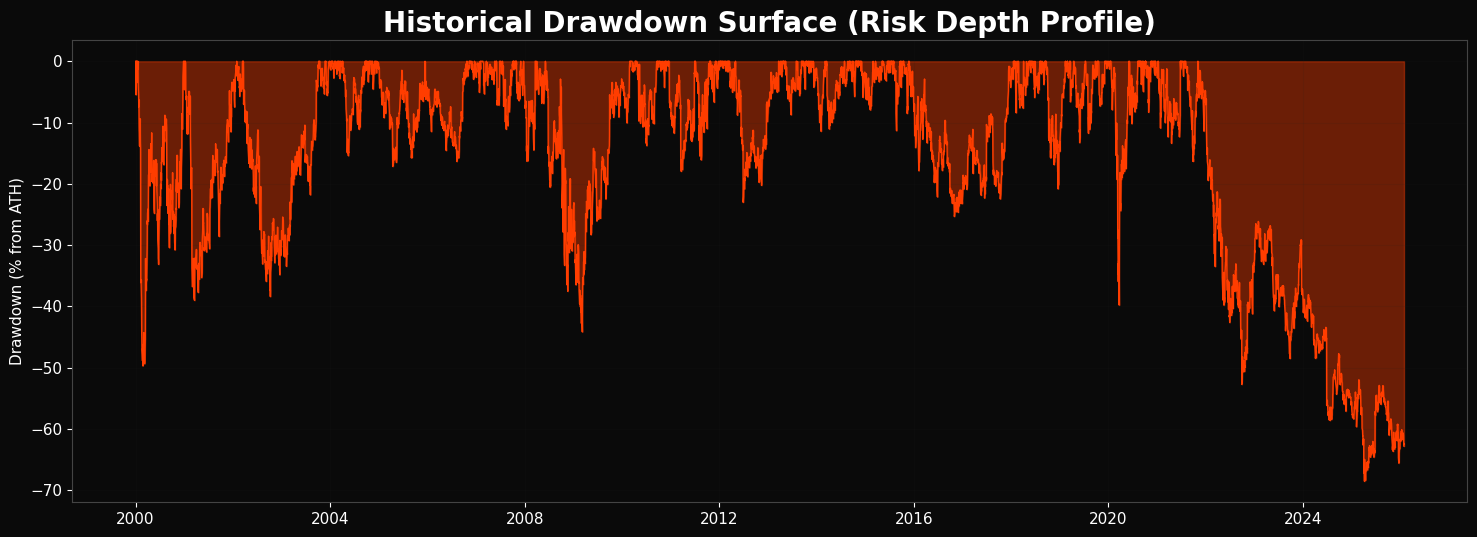

In [9]:
rolling_max = df['Close'].cummax()
drawdown = (df['Close'] / rolling_max) - 1

plt.figure(figsize=(18, 6))
plt.fill_between(df['Date'], drawdown * 100, 0, color=VIBRANT_RED, alpha=0.4)
plt.plot(df['Date'], drawdown * 100, color=VIBRANT_RED, lw=1)
plt.title("Historical Drawdown Surface (Risk Depth Profile)")
plt.ylabel("Drawdown (% from ATH)")
plt.grid(alpha=0.1)
plt.show()

## 9. Performance Tiering: Annual Return Distribution (Pie Chart)
Categorizing historical years based on their total market return magnitude.

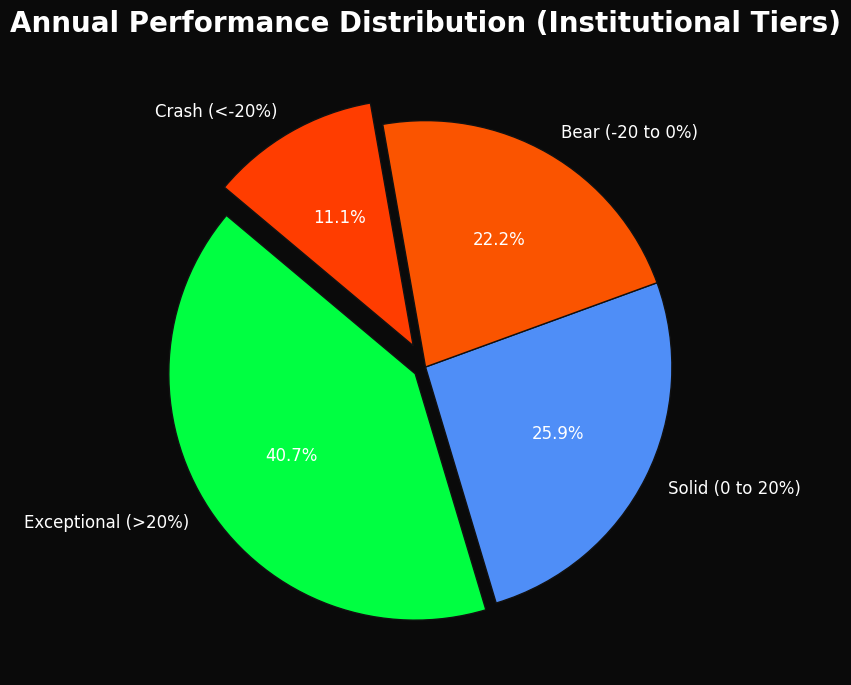

In [10]:
annual_rets = df.groupby('Year').apply(lambda x: ((x['Close'].iloc[-1] / x['Open'].iloc[0]) - 1) * 100)
tiers = pd.cut(annual_rets, bins=[-np.inf, -20, 0, 20, np.inf], 
               labels=['Crash (<-20%)', 'Bear (-20 to 0%)', 'Solid (0 to 20%)', 'Exceptional (>20%)'])
tier_counts = tiers.value_counts().reindex(['Exceptional (>20%)', 'Solid (0 to 20%)', 'Bear (-20 to 0%)', 'Crash (<-20%)'])

plt.figure(figsize=(10, 8))
colors = [VIBRANT_GREEN, ACCENT_BLUE, NIKE_ORANGE, VIBRANT_RED]
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=140, explode=[0.05, 0, 0, 0.1], 
        textprops={'color': TEXT_WHITE, 'size': 12}, wedgeprops={'edgecolor': '#111'})
plt.title("Annual Performance Distribution (Institutional Tiers)", pad=20)
plt.show()

## 10. Volume Profile Analysis
Identifying price levels with dense trading history.

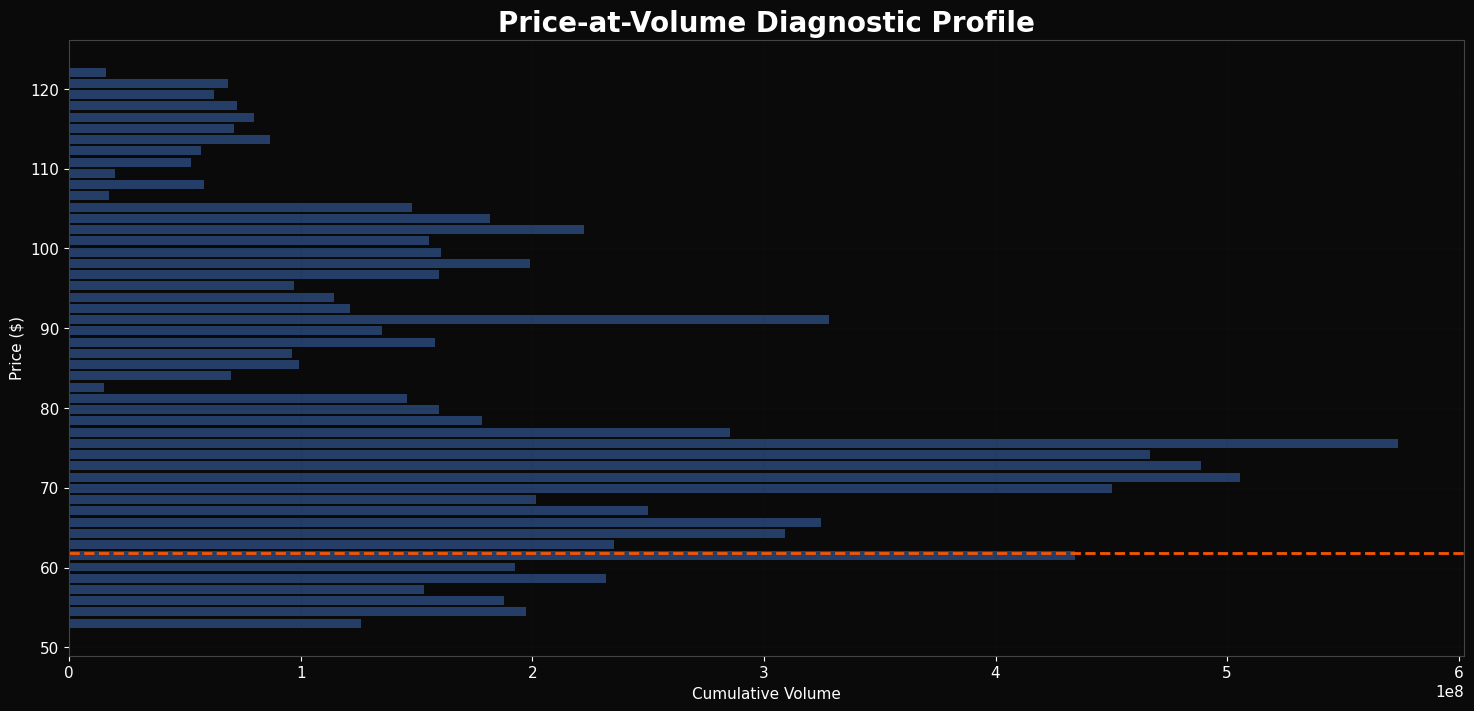

In [11]:
plt.figure(figsize=(18, 8))
hist_data = df.tail(756)
counts, edges = np.histogram(hist_data['Close'], bins=50, weights=hist_data['Volume'])
centers = (edges[:-1] + edges[1:]) / 2
plt.barh(centers, counts, height=(centers[1]-centers[0])*0.8, color=ACCENT_BLUE, alpha=0.4)
plt.axhline(curr['Close'], color=NIKE_ORANGE, ls='--', lw=2)
plt.title("Price-at-Volume Diagnostic Profile")
plt.xlabel("Cumulative Volume")
plt.ylabel("Price ($)")
plt.grid(alpha=0.1)
plt.show()

## 11. Seasonality Analysis: Monthly Return Distribution
Boxplot analysis of monthly performance variance across 26 years.

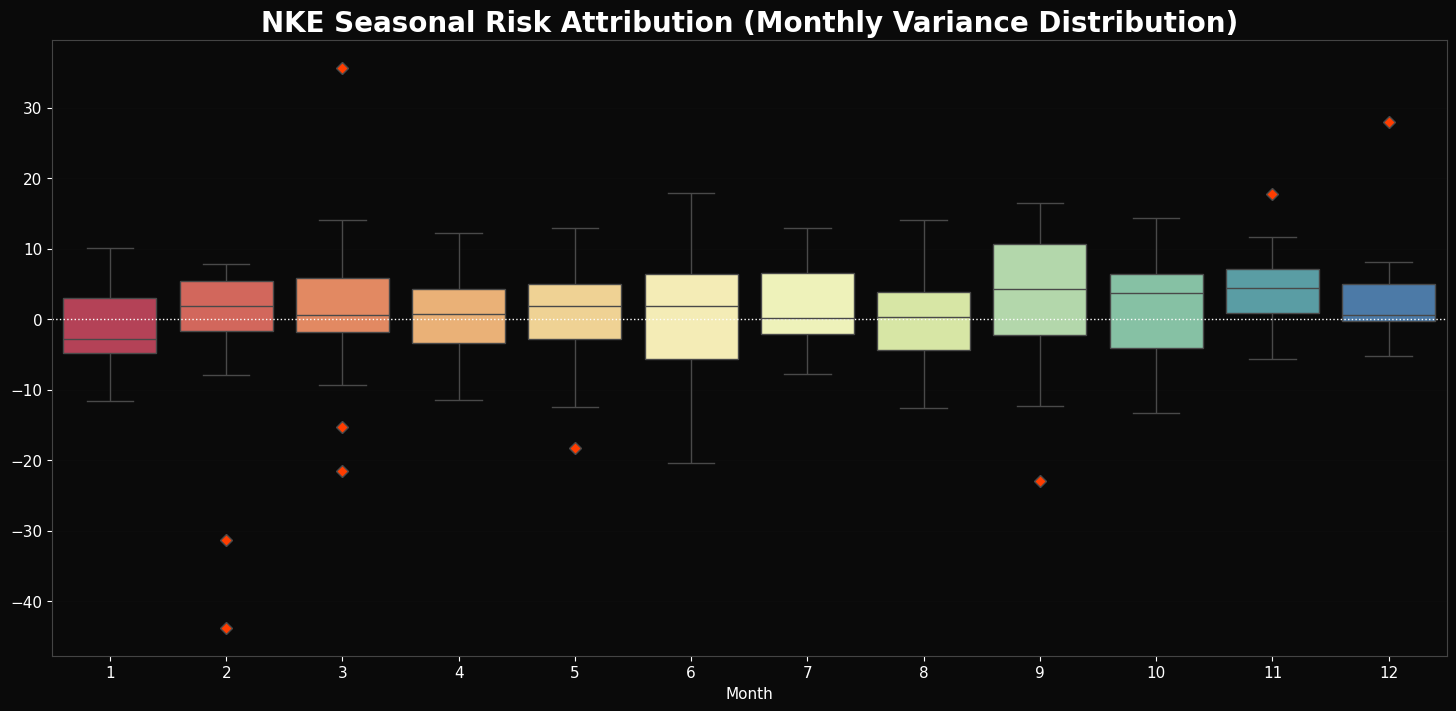

In [12]:
monthly_rets = df.groupby(['Year', 'Month'])['Daily_Return'].sum().unstack() * 100
plt.figure(figsize=(18, 8))
sns.boxplot(data=monthly_rets, palette="Spectral", flierprops=dict(markerfacecolor=VIBRANT_RED, marker='D'))
plt.title("NKE Seasonal Risk Attribution (Monthly Variance Distribution)")
plt.axhline(0, color=TEXT_WHITE, ls=':', lw=1)
plt.grid(axis='y', alpha=0.1)
plt.show()

## 12. Institutional Win-Rate: Monthly Success Probability (Pie Chart)
Which months have the highest probability of delivering a positive yield?

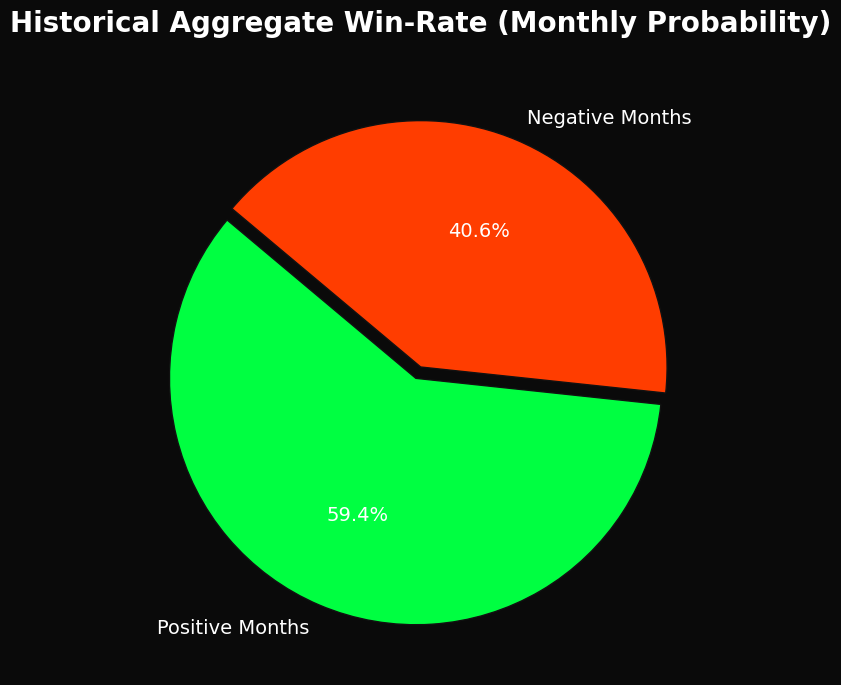

In [13]:
pos_months = (monthly_rets > 0).sum().sum()
total_months = monthly_rets.count().sum()
neg_months = total_months - pos_months

plt.figure(figsize=(10, 8))
plt.pie([pos_months, neg_months], labels=['Positive Months', 'Negative Months'], 
        autopct='%1.1f%%', colors=[VIBRANT_GREEN, VIBRANT_RED], 
        startangle=140, explode=[0.05, 0], 
        textprops={'color': TEXT_WHITE, 'size': 14}, wedgeprops={'edgecolor': '#111'})
plt.title("Historical Aggregate Win-Rate (Monthly Probability)", pad=20)
plt.show()

## 13. Future Path Probability: Monte Carlo Price Simulation
Projecting 1,000 potential price trajectories for the next 252 trading days.

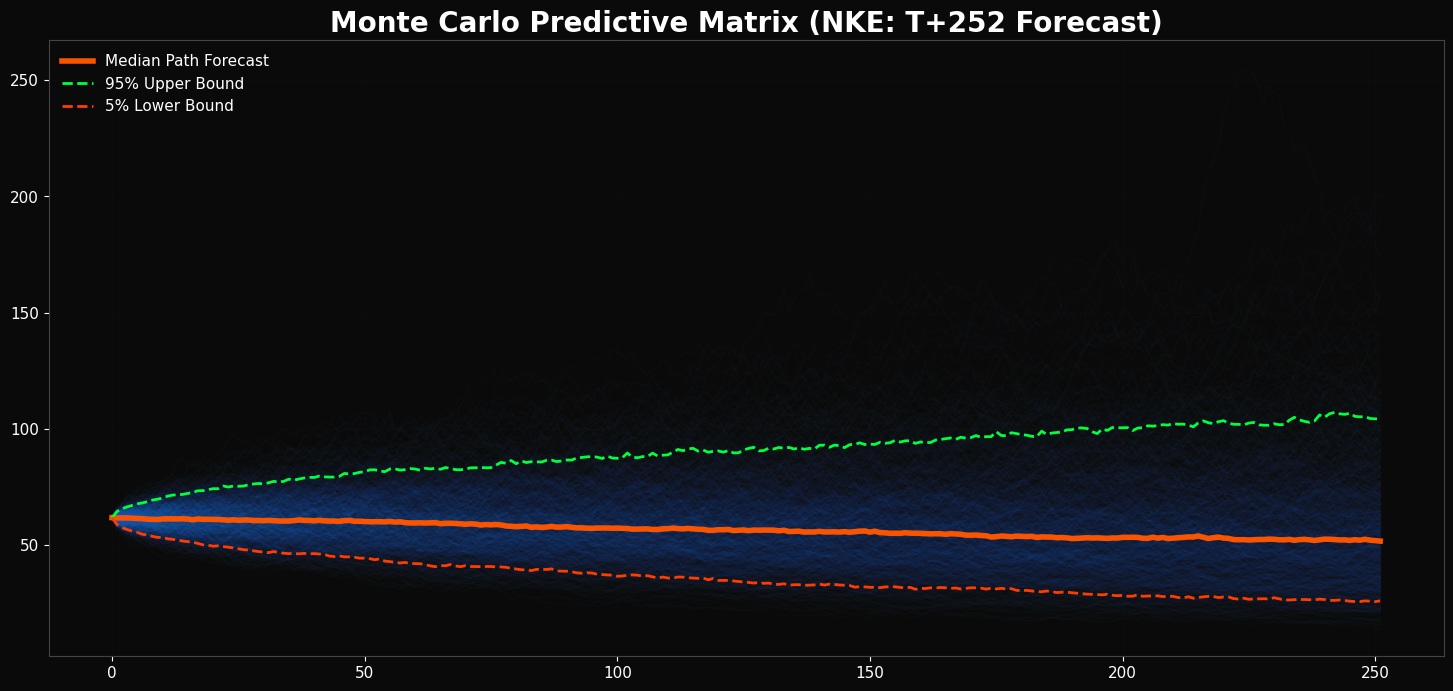

In [14]:
days_to_sim = 252
num_sims = 1000
last_price = df['Close'].iloc[-1]
daily_vol = df['Daily_Return'].tail(252).std()
daily_drift = df['Daily_Return'].tail(252).mean()
sim_results = np.zeros((days_to_sim, num_sims))
for s in range(num_sims):
    prices = [last_price]
    for d in range(days_to_sim - 1):
        prices.append(prices[-1] * (1 + np.random.normal(daily_drift, daily_vol)))
    sim_results[:, s] = prices

plt.figure(figsize=(18, 8))
plt.plot(sim_results, color=ACCENT_BLUE, alpha=0.015)
plt.plot(np.percentile(sim_results, 50, axis=1), color=NIKE_ORANGE, lw=4, label='Median Path Forecast')
plt.plot(np.percentile(sim_results, 95, axis=1), color=VIBRANT_GREEN, lw=2, ls='--', label='95% Upper Bound')
plt.plot(np.percentile(sim_results, 5, axis=1), color=VIBRANT_RED, lw=2, ls='--', label='5% Lower Bound')
plt.title(f"Monte Carlo Predictive Matrix (NKE: T+{days_to_sim} Forecast)")
plt.legend(frameon=False)
plt.grid(alpha=0.1)
plt.show()

## 14. Executive Diagnostic Summary
Final quantitative synthesis of institutional facts for the Nike equity profile.

In [16]:
avg_vol = df['Vol63'].iloc[-1]
m_target = np.percentile(sim_results, 50, axis=1)[-1]
draw_val = drawdown.iloc[-1]*100

diagnostic_html = f"""
<div style="background: #161923; padding: 25px; border-radius: 12px; border-left: 5px solid {NIKE_ORANGE};">
    <h3 style="color: {NIKE_ORANGE}; margin-top:0">Sitt Min Thar , Analyst Executive Summary</h3>
    <ul style="color: #ccc; line-height: 1.8;">
        <li><b>Technical Posture:</b> Persistent 'Death Cross' regime with price action compressed below multi-year supply floors.</li>
        <li><b>Volume Intensity:</b> Price-at-Volume profile shows structural overhead resistance at historical accumulation zones.</li>
        <li><b>Risk Attribution:</b> Annualized Volatility regime at <b>{avg_vol:.2f}%</b> with a drawdown of <b>{draw_val:.2f}%</b>.</li>
        <li><b>Seasonal Outlook:</b> Historical variance suggests high volatility outliers in Q2 cycles.</li>
        <li><b>Prediction Matrix:</b> Monte Carlo median trajectory projects a target value of <b>${m_target:.2f}</b> by FY2026.</li>
    </ul>
</div>
"""
display(HTML(diagnostic_html))